# Análisis Exploratorio de Datos (EDA)
## Operaciones de tienda — cadena de retail en México

**Objetivo:** entender la estructura, calidad y patrones del dataset antes de definir
y construir la solución de negocio.

**Datos:** transacciones diarias por tienda y categoría (`transactions.csv`),
características de tiendas (`stores.csv`) y calendario de eventos (`calendar.csv`),
del **2023-01-01** al **2024-02-29** (~14 meses).

**Contenido:**

1. Configuración
2. Carga de datos
3. Validación estructural (completitud del panel, duplicados)
4. Calidad de datos (valores faltantes)
5. Consistencia interna de las métricas
6. Análisis univariado
7. Series de tiempo y estacionalidad
8. Dimensión tienda (formato, región)
9. Efecto de promociones
10. Auditoría de `replenishment_signal` (riesgo de *leakage*)
11. Conclusiones y siguientes pasos

## 1. Configuración

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración global de visualización y pandas
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (13, 4)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Ruta a los datos (relativa a la carpeta notebooks/)
DATA_DIR = "../data"

## 2. Carga de datos

In [2]:
transactions = pd.read_csv(f"{DATA_DIR}/transactions.csv", parse_dates=["date"])
stores = pd.read_csv(f"{DATA_DIR}/stores.csv")
calendar = pd.read_csv(f"{DATA_DIR}/calendar.csv", parse_dates=["date"])

print(f"transactions: {transactions.shape[0]:>8,} filas x {transactions.shape[1]} columnas")
print(f"stores:       {stores.shape[0]:>8,} filas x {stores.shape[1]} columnas")
print(f"calendar:     {calendar.shape[0]:>8,} filas x {calendar.shape[1]} columnas")

transactions:  203,958 filas x 13 columnas
stores:             80 filas x 9 columnas
calendar:          425 filas x 15 columnas


In [3]:
# Vista rápida de cada tabla
display(transactions.head(3))
display(stores.head(3))
display(calendar.head(3))

,date,store_id,category,total_transactions,cash_transactions,card_transactions,amount_total,amount_cash,amount_card,units_sold,avg_ticket,has_promotion,replenishment_signal
0,2023-01-01,STR_001,Abarrotes,833,NaN,326,"244,732.98",NaN,"101,822.79","2,299.00",NaN,0,NaN
1,2023-01-02,STR_001,Abarrotes,1298,750.00,548,"373,235.09","222,834.25","150,400.84","3,011.00",287.55,0,NaN
2,2023-01-03,STR_001,Abarrotes,1614,931.00,683,"404,249.92","239,802.59","164,447.33","3,652.00",250.46,0,"1,546.00"


,store_id,store_format,region,size_sqm,num_checkouts,opening_year,socioeconomic_level,has_pharmacy,has_fuel_station
0,STR_001,Supercenter,Norte,11072,37,2020,B,True,False
1,STR_002,Supercenter,Occidente,13502,22,2020,C+,True,False
2,STR_003,Supercenter,Occidente,13759,28,2019,C,True,True


,date,day_of_week,day_name,week_of_year,month,year,quarter,season,is_holiday,holiday_name,is_payday,is_weekend,is_navidad_season,is_buen_fin,is_semana_santa
0,2023-01-01,6,Sunday,52,1,2023,1,Invierno,True,Año Nuevo,False,True,True,False,False
1,2023-01-02,0,Monday,1,1,2023,1,Invierno,False,NaN,False,False,True,False,False
2,2023-01-03,1,Tuesday,1,1,2023,1,Invierno,False,NaN,False,False,True,False,False


## 3. Validación estructural

El dataset debería ser un panel completo: una fila por combinación
`fecha x tienda x categoría`. Verificamos cuántas combinaciones faltan
(el diccionario advierte que "algunas tiendas tienen periodos completos sin datos"),
la continuidad del rango de fechas y la ausencia de duplicados.

In [4]:
n_stores = transactions["store_id"].nunique()
n_categories = transactions["category"].nunique()
n_dates = calendar["date"].nunique()

esperadas = n_dates * n_stores * n_categories
print(f"Tiendas: {n_stores} | Categorías: {n_categories} | Días: {n_dates}")
print(f"Filas esperadas (panel completo): {esperadas:,}")
print(f"Filas observadas:                 {len(transactions):,}")
print(f"Faltantes:                        {esperadas - len(transactions):,}")

# Duplicados en la llave del panel
dups = transactions.duplicated(subset=["date", "store_id", "category"]).sum()
print(f"Duplicados (date, store_id, category): {dups}")

# Rango y continuidad de fechas
fechas_faltantes = pd.date_range(transactions["date"].min(), transactions["date"].max()).difference(
    transactions["date"].unique()
)
print(f"Rango: {transactions['date'].min().date()} a {transactions['date'].max().date()}")
print(f"Fechas sin ninguna fila: {len(fechas_faltantes)}")

Tiendas: 80 | Categorías: 6 | Días: 425
Filas esperadas (panel completo): 204,000
Filas observadas:                 203,958
Faltantes:                        42
Duplicados (date, store_id, category): 0
Rango: 2023-01-01 a 2024-02-29
Fechas sin ninguna fila: 0


In [5]:
# ¿Qué combinaciones tienda/categoría/día faltan? ¿Se concentran en tiendas específicas?
full_index = pd.MultiIndex.from_product(
    [calendar["date"].unique(), sorted(transactions["store_id"].unique()),
     sorted(transactions["category"].unique())],
    names=["date", "store_id", "category"],
)
faltantes = (
    full_index.difference(transactions.set_index(["date", "store_id", "category"]).index)
    .to_frame(index=False)
)

if faltantes.empty:
    print("El panel está completo: no faltan combinaciones.")
else:
    resumen = (
        faltantes.groupby("store_id")
        .agg(filas_faltantes=("date", "size"), dias=("date", "nunique"),
             desde=("date", "min"), hasta=("date", "max"))
        .sort_values("filas_faltantes", ascending=False)
    )
    display(resumen)

,filas_faltantes,dias,desde,hasta
store_id,,,,
STR_055,18,3,2024-02-18,2024-02-20
STR_045,12,2,2023-02-01,2023-02-02
STR_064,12,2,2023-02-22,2023-02-23


## 4. Calidad de datos: valores faltantes

Además de filas ausentes, hay nulos dentro de las filas
(fallas de POS y conectividad según el diccionario). Cuantificamos cuánto falta,
en qué columnas, y si los nulos se concentran en el tiempo o en tiendas específicas —
esto determina la estrategia de imputación más adelante.

In [6]:
nulos = transactions.isna().sum().to_frame("n_nulos")
nulos["pct"] = 100 * nulos["n_nulos"] / len(transactions)
nulos[nulos["n_nulos"] > 0].sort_values("n_nulos", ascending=False)

,n_nulos,pct
cash_transactions,12123,5.94
amount_cash,12123,5.94
units_sold,6118,3.00
avg_ticket,4874,2.39
replenishment_signal,960,0.47


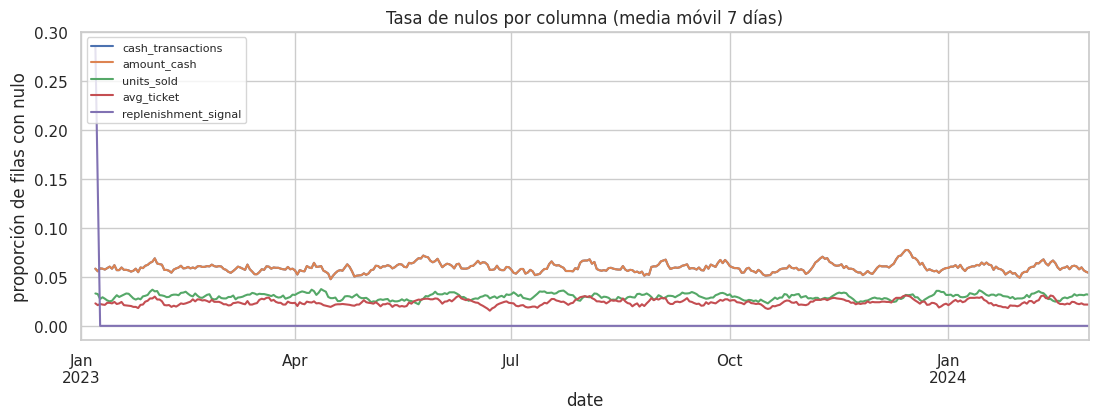

In [7]:
# Evolución temporal de la tasa de nulos por columna
cols_con_nulos = ["cash_transactions", "amount_cash", "units_sold", "avg_ticket", "replenishment_signal"]

tasa_diaria = transactions.set_index("date")[cols_con_nulos].isna().groupby(level=0).mean()
ax = tasa_diaria.rolling(7).mean().plot(title="Tasa de nulos por columna (media móvil 7 días)")
ax.set_ylabel("proporción de filas con nulo")
ax.legend(loc="upper left", fontsize=8)
plt.show()

In [8]:
# ¿Los nulos se concentran en tiendas específicas?
nulos_tienda = transactions.groupby("store_id")[cols_con_nulos].apply(lambda g: g.isna().mean())
print("Tiendas con mayor tasa de nulos (top 10, ordenado por cash_transactions):")
nulos_tienda.sort_values("cash_transactions", ascending=False).head(10)

Tiendas con mayor tasa de nulos (top 10, ordenado por cash_transactions):


,cash_transactions,amount_cash,units_sold,avg_ticket,replenishment_signal
store_id,,,,,
STR_005,0.07,0.07,0.03,0.03,0.00
STR_054,0.07,0.07,0.03,0.03,0.00
STR_055,0.07,0.07,0.03,0.03,0.00
STR_079,0.07,0.07,0.03,0.02,0.00
STR_029,0.07,0.07,0.03,0.03,0.00
STR_053,0.07,0.07,0.03,0.03,0.00
STR_049,0.07,0.07,0.03,0.03,0.00
STR_006,0.07,0.07,0.03,0.03,0.00
STR_020,0.07,0.07,0.03,0.03,0.00


## 5. Consistencia interna

Las métricas tienen relaciones contables que deben cumplirse:

- `cash_transactions + card_transactions = total_transactions`
- `amount_cash + amount_card = amount_total`
- `avg_ticket ≈ amount_total / total_transactions`
- Ningún valor numérico debería ser negativo.

In [9]:
# Consistencia de conteos de transacciones (solo filas sin nulos en cash)
m = transactions["cash_transactions"].notna()
diff_trans = (
    transactions.loc[m, "cash_transactions"] + transactions.loc[m, "card_transactions"]
    - transactions.loc[m, "total_transactions"]
)
print(f"Filas donde cash + card != total_transactions: {(diff_trans != 0).sum():,} de {m.sum():,}")

# Consistencia de montos
m = transactions["amount_cash"].notna()
diff_amt = (
    transactions.loc[m, "amount_cash"] + transactions.loc[m, "amount_card"]
    - transactions.loc[m, "amount_total"]
)
print(f"Máx |amount_cash + amount_card - amount_total|: {diff_amt.abs().max():.4f} MXN")

# avg_ticket vs recalculado
m = transactions["avg_ticket"].notna()
recalc = transactions.loc[m, "amount_total"] / transactions.loc[m, "total_transactions"]
print(f"Máx |avg_ticket - amount_total/total_transactions|: {(transactions.loc[m, 'avg_ticket'] - recalc).abs().max():.4f}")

# Valores negativos
num_cols = transactions.select_dtypes("number").columns
negativos = (transactions[num_cols] < 0).sum()
print("\nValores negativos por columna:")
print(negativos[negativos > 0] if negativos.any() else "  ninguno")

Filas donde cash + card != total_transactions: 38,295 de 191,835
Máx |amount_cash + amount_card - amount_total|: 0.0000 MXN
Máx |avg_ticket - amount_total/total_transactions|: 434.1255

Valores negativos por columna:
  ninguno


## 6. Análisis univariado

In [10]:
transactions.describe().T

,count,mean,min,25%,50%,75%,max,std
date,203958,2023-08-01 00:03:08.085782272,2023-01-01 00:00:00,2023-04-17 00:00:00,2023-08-01 00:00:00,2023-11-15 00:00:00,2024-02-29 00:00:00,NaN
total_transactions,"203,958.00",613.51,14.00,228.00,424.00,783.00,"15,194.00",631.77
cash_transactions,"191,835.00",273.98,3.00,77.00,169.00,352.00,"8,387.00",323.69
card_transactions,"203,958.00",313.10,11.00,136.00,234.00,399.00,"6,827.00",286.56
amount_total,"203,958.00","170,581.26","6,922.32","78,798.17","129,965.23","213,323.91","4,050,995.63","150,445.65"
amount_cash,"191,835.00","71,623.69","2,721.28","30,519.27","51,462.28","86,819.46","2,294,517.17","71,687.13"
amount_card,"203,958.00","98,908.20","4,201.04","44,898.69","74,877.42","124,418.91","2,269,315.38","88,072.57"
units_sold,"197,840.00","1,175.41",22.00,418.00,793.00,"1,487.00","31,936.00","1,264.96"
avg_ticket,"199,084.00",411.76,69.86,182.44,297.03,534.14,"1,931.74",303.64
has_promotion,"203,958.00",0.20,0.00,0.00,0.00,0.00,1.00,0.40


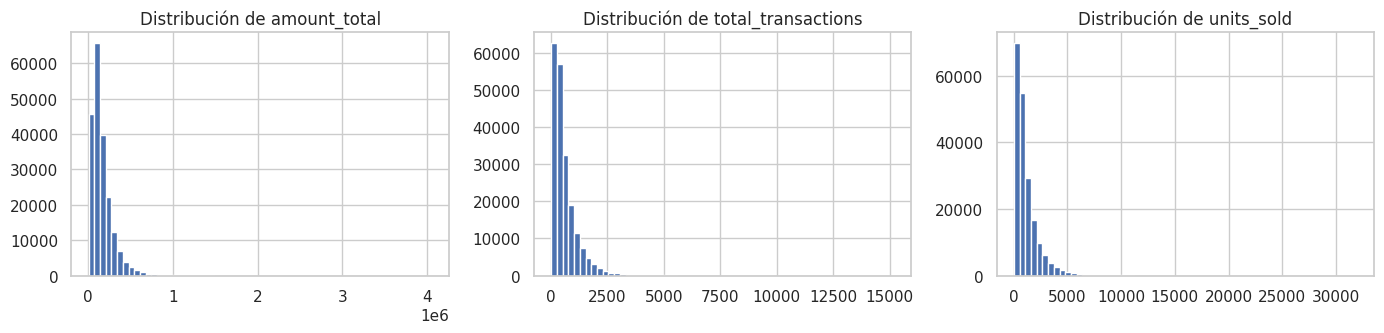

In [11]:
# Distribución de las métricas principales
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["amount_total", "total_transactions", "units_sold"]):
    transactions[col].dropna().hist(bins=60, ax=ax)
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

## 7. Series de tiempo y estacionalidad

Buscamos los patrones que cualquier modelo deberá capturar: tendencia,
estacionalidad semanal, quincenas y eventos (Buen Fin, Navidad, Semana Santa).

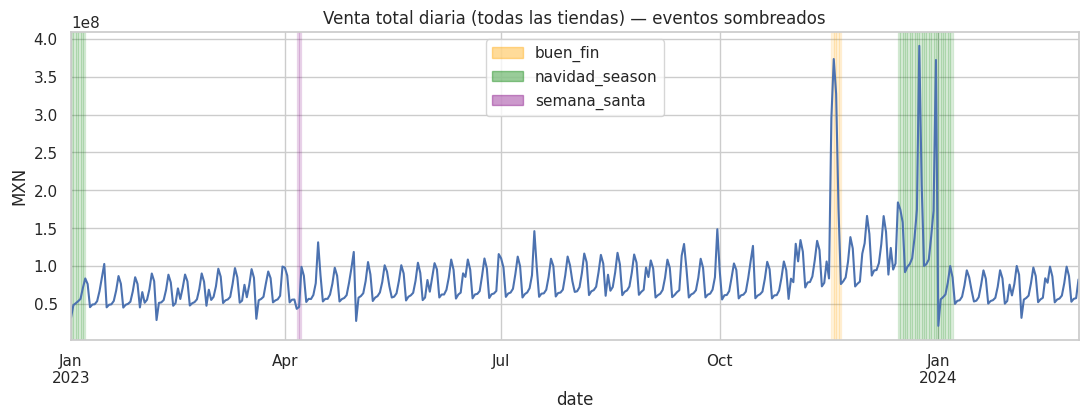

In [12]:
# Venta total diaria con eventos sombreados
daily = transactions.groupby("date")["amount_total"].sum()
ax = daily.plot(title="Venta total diaria (todas las tiendas) — eventos sombreados")
ax.set_ylabel("MXN")

eventos = {"is_buen_fin": "orange", "is_navidad_season": "green", "is_semana_santa": "purple"}
for col, color in eventos.items():
    for d in calendar.loc[calendar[col], "date"]:
        ax.axvspan(d, d + pd.Timedelta(days=1), color=color, alpha=0.12)

import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color=c, alpha=0.4, label=e.replace("is_", "")) for e, c in eventos.items()])
plt.show()

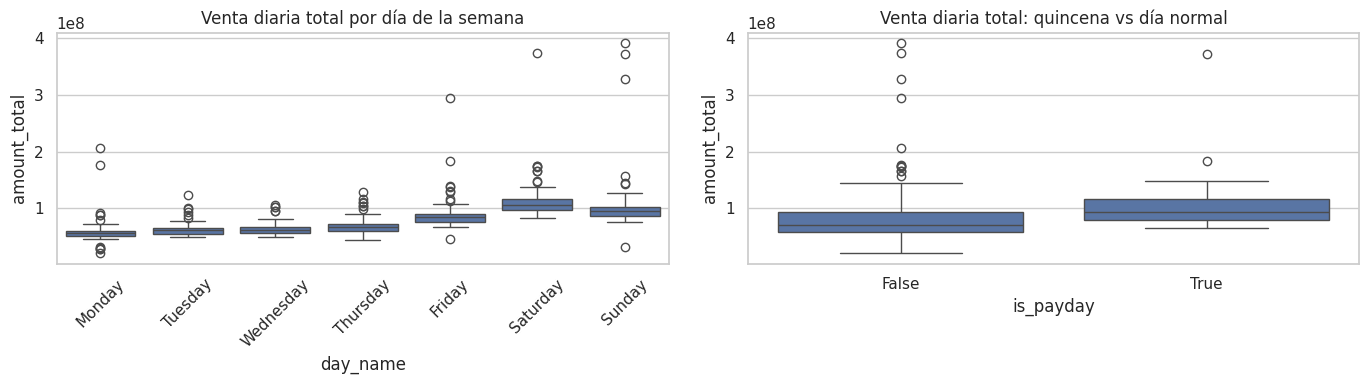

In [13]:
# Estacionalidad semanal y efecto quincena
trx_cal = transactions.merge(
    calendar[["date", "day_name", "is_payday", "is_holiday"]], on="date", how="left"
)
venta_dia = trx_cal.groupby(["date", "day_name", "is_payday"], as_index=False)["amount_total"].sum()

orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=venta_dia, x="day_name", y="amount_total", order=orden, ax=axes[0])
axes[0].set_title("Venta diaria total por día de la semana")
axes[0].tick_params(axis="x", rotation=45)
sns.boxplot(data=venta_dia, x="is_payday", y="amount_total", ax=axes[1])
axes[1].set_title("Venta diaria total: quincena vs día normal")
plt.tight_layout()
plt.show()

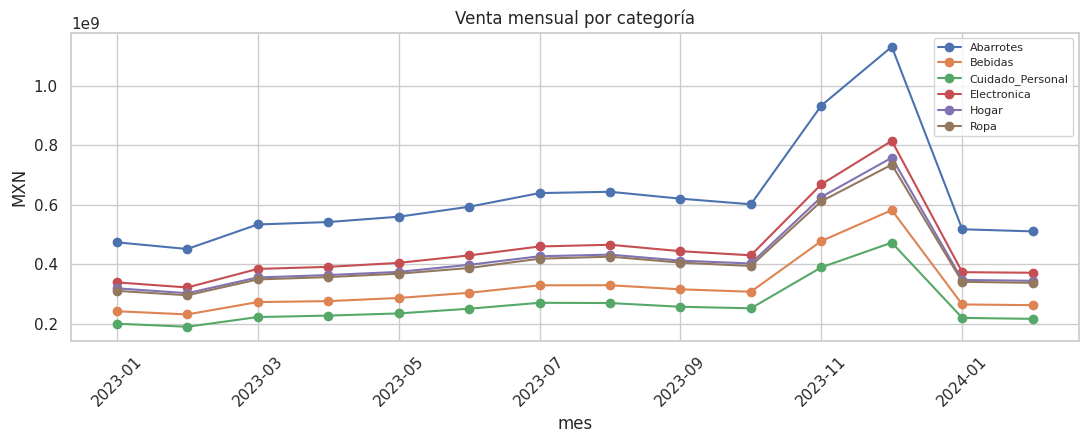

In [14]:
# Evolución mensual por categoría
cat_mes = (
    transactions.assign(mes=transactions["date"].dt.to_period("M").astype(str))
    .groupby(["mes", "category"])["amount_total"].sum()
    .unstack()
)
ax = cat_mes.plot(title="Venta mensual por categoría", marker="o")
ax.set_ylabel("MXN")
ax.legend(fontsize=8)
plt.xticks(rotation=45)
plt.show()

## 8. Dimensión tienda

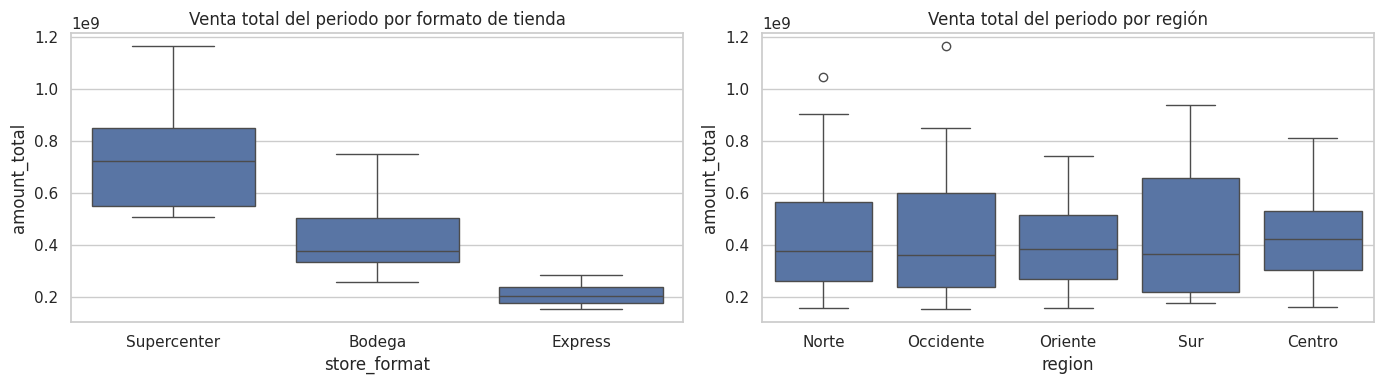

store_format
Bodega         35
Express        25
Supercenter    20
Name: count, dtype: int64 

region
Occidente    20
Oriente      18
Norte        17
Sur          13
Centro       12
Name: count, dtype: int64


In [15]:
trx_full = transactions.merge(stores, on="store_id", how="left")

# Venta total por tienda, coloreada por formato y región
venta_tienda = (
    trx_full.groupby(["store_id", "store_format", "region"], as_index=False)["amount_total"].sum()
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=venta_tienda, x="store_format", y="amount_total", ax=axes[0])
axes[0].set_title("Venta total del periodo por formato de tienda")
sns.boxplot(data=venta_tienda, x="region", y="amount_total", ax=axes[1])
axes[1].set_title("Venta total del periodo por región")
plt.tight_layout()
plt.show()

print(stores["store_format"].value_counts(), "\n")
print(stores["region"].value_counts())

In [16]:
# Mix de categorías según formato: ¿los formatos venden distinto?
mix = (
    trx_full.pivot_table(index="store_format", columns="category",
                         values="amount_total", aggfunc="sum")
)
(100 * mix.div(mix.sum(axis=1), axis=0)).round(1)

category,Abarrotes,Bebidas,Cuidado_Personal,Electronica,Hogar,Ropa
store_format,,,,,,
Bodega,25.10,12.90,10.50,18.10,16.80,16.50
Express,25.10,12.90,10.60,18.10,16.90,16.40
Supercenter,25.20,12.90,10.50,18.10,16.80,16.50


## 9. Efecto de promociones

In [17]:
# Frecuencia de promociones y venta media con/sin promoción, por categoría
freq_promo = transactions.groupby("category")["has_promotion"].mean().mul(100).round(1)

uplift = (
    transactions.groupby(["category", "has_promotion"])["amount_total"].mean().unstack()
    .rename(columns={0: "sin_promo", 1: "con_promo"})
)
uplift["uplift_%"] = (100 * (uplift["con_promo"] / uplift["sin_promo"] - 1)).round(1)
uplift["dias_promo_%"] = freq_promo
uplift

has_promotion,sin_promo,con_promo,uplift_%,dias_promo_%
category,,,,
Abarrotes,"257,439.68","257,055.48",-0.10,19.90
Bebidas,"131,660.31","132,402.35",0.60,20.00
Cuidado_Personal,"108,095.67","107,535.29",-0.50,19.90
Electronica,"184,943.75","186,335.43",0.80,20.00
Hogar,"172,314.95","172,857.56",0.30,20.20
Ropa,"168,872.00","167,936.90",-0.60,19.90


## 10. Auditoría de `replenishment_signal`

El diccionario indica que esta señal se calcula **"con base en la demanda observada"**
y tiene nulos al final del periodo. Si está construida con la demanda del mismo día
(o del futuro), usarla como *feature* en un modelo de pronóstico sería **data leakage**:
en producción no estaría disponible al momento de predecir. La auditamos antes de
decidir si se usa.

In [18]:
# ¿Dónde están los nulos de la señal? (tasa por día, últimos 15 días)
tasa_nulos_senal = transactions.groupby("date")["replenishment_signal"].apply(lambda s: s.isna().mean())
print("Tasa de nulos de replenishment_signal en los últimos 15 días:")
print(tasa_nulos_senal.tail(15).to_string())

Tasa de nulos de replenishment_signal en los últimos 15 días:
date
2024-02-15   0.00
2024-02-16   0.00
2024-02-17   0.00
2024-02-18   0.00
2024-02-19   0.00
2024-02-20   0.00
2024-02-21   0.00
2024-02-22   0.00
2024-02-23   0.00
2024-02-24   0.00
2024-02-25   0.00
2024-02-26   0.00
2024-02-27   0.00
2024-02-28   0.00
2024-02-29   0.00


,corr_con_units_sold
lag (días hacia atrás),
-3,0.75
-2,0.77
-1,0.80
0,0.81
1,0.82
2,0.82
3,0.82
7,0.75


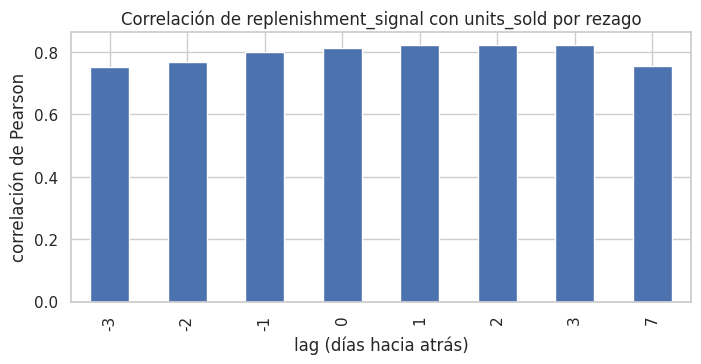

In [19]:
# Correlación de la señal con la demanda en distintos rezagos.
# Si la correlación máxima está en lag 0 (o negativo), la señal "conoce" el presente/futuro.
panel = transactions.sort_values(["store_id", "category", "date"]).copy()
grupo = panel.groupby(["store_id", "category"])["units_sold"]

correlaciones = {}
for lag in [-3, -2, -1, 0, 1, 2, 3, 7]:
    correlaciones[lag] = panel["replenishment_signal"].corr(grupo.shift(lag))

corr_df = pd.Series(correlaciones, name="corr_con_units_sold").to_frame()
corr_df.index.name = "lag (días hacia atrás)"
display(corr_df)

ax = corr_df.plot(kind="bar", legend=False, figsize=(8, 3.5),
                  title="Correlación de replenishment_signal con units_sold por rezago")
ax.set_ylabel("correlación de Pearson")
plt.show()

## 11. Conclusiones y siguientes pasos

### Hallazgos principales

**Estructura.** Panel casi completo: 203,958 de 204,000 combinaciones esperadas (80 tiendas x 6 categorías x 425 días). Solo faltan 42 filas, concentradas en 3 tiendas con huecos de 2–3 días (`STR_055`, `STR_045`, `STR_064`). Sin duplicados ni fechas ausentes.

**Calidad de datos.**
- `cash_transactions` / `amount_cash`: ~5.9% de nulos, repartidos de forma homogénea entre tiendas (~7% cada una) — consistente con fallas aleatorias de POS, no con tiendas problemáticas.
- `units_sold` (3.0%) y `avg_ticket` (2.4%) con nulos moderados.
- `replenishment_signal`: los nulos (0.47%) están en los **primeros 2 días** del periodo, no en los últimos como indica el diccionario — patrón típico de una ventana móvil que requiere historia.

**Consistencia.**
- `amount_cash + amount_card = amount_total` se cumple exactamente.
- `cash + card < total_transactions` en el 20% de las filas (nunca mayor): existen transacciones no clasificadas por método de pago.
- `avg_ticket` coincide con `amount_total / total_transactions` en la mayoría de filas (mediana de diferencia ≈ 0) pero con desviaciones de hasta 434 MXN en la cola — usar la versión recalculada.
- Sin valores negativos.

**Patrones de negocio.**
- Fuerte estacionalidad semanal (fin de semana) y efecto quincena visible.
- Picos claros en Buen Fin y temporada navideña; caída post-navideña.
- Bodega (35 tiendas), Express (25) y Supercenter (20); el mix de categorías es prácticamente idéntico entre formatos (~25% Abarrotes, ~18% Electrónica...), por lo que el formato diferencia el nivel de venta, no la composición.
- **Promociones sin uplift aparente** en venta por tienda-día (−0.6% a +0.8% según categoría, con ~20% de días en promoción) — comparación descriptiva, no causal; merece análisis más cuidadoso si el problema elegido involucra promos.

**Riesgo de leakage en `replenishment_signal`.** Correlación ~0.8 con `units_sold` en lags 0 a 3, y nulos solo al inicio del periodo: la señal es esencialmente una ventana móvil de la demanda reciente que **incluye el día corriente**. Usarla como feature en un modelo de pronóstico filtraría información del propio día a predecir. **Decisión: excluirla del modelado** (o reconstruirla solo con lags ≥ 1 debidamente desplazados).

### Siguientes pasos

1. Definir el problema de negocio: el dataset apunta a **pronóstico de demanda diaria por tienda-categoría** (soporta reposición de inventario y planeación de personal).
2. Estrategia de imputación simple para nulos de `units_sold` (los de cash/amount_cash no afectan la variable objetivo).
3. Feature engineering: calendario (quincena, festivos, eventos), lags y ventanas móviles correctamente desplazadas, atributos de tienda.
4. Esquema de validación temporal (train/test split por fecha, sin fuga de información).